# SBERT Comparison — Accuracy vs. Interpretability

**Author:** Morchid Saad — INSEA — 3D Smart Factory

**Project:** Geometry-Aware Optimal Transport for Interpretable Semantic Textual Similarity (PFE)

## Abstract

This notebook benchmarks Sentence-BERT (SBERT) against the Euclidean WMD and cosine baseline pipelines from the geometric comparison notebook, using the same 1,500 STS-B validation pairs. The goal is not to compete with SBERT on accuracy — contextual models are expected to dominate — but to quantify the accuracy–interpretability tradeoff that motivates this project. WMD provides a transparent transport plan showing which words align and how much mass flows between them; SBERT produces a single opaque cosine score. This notebook makes that contrast concrete.

This is the fourth and final notebook in the experimental pipeline. The geometric comparison notebook established the Euclidean WMD baseline; the HyperLex diagnostic validated hyperbolic geometry on a word-level task; the native hyperbolic WMD notebook tested Tifrea Poincaré GloVe on STS-B. This notebook closes the pipeline by situating all results against the dominant black-box approach.

## Notebook structure

| Section | Content |
|---|---|
| 1 | Setup — imports, configuration, STS-B validation |
| 2 | SBERT evaluation — encode, cosine similarity, Spearman |
| 3 | Load geometric comparison results — Euclidean WMD and cosine baseline from saved CSV |
| 4 | Comparison table and visualization — three methods side by side |
| 5 | Interpretability showcase — transport plan vs. SBERT cosine on one example pair |
| 6 | Conclusions |

## 1. Setup

In [1]:
# ---- Imports --------------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
from pathlib import Path
from collections import Counter
from scipy.stats import spearmanr, pearsonr
from tqdm.auto import tqdm

# SBERT
from sentence_transformers import SentenceTransformer, util

# STS-B
from datasets import load_dataset

# For interpretability showcase
import gensim.downloader as api
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import ot  # POT library

import warnings
warnings.filterwarnings("ignore")

print("Imports complete.")

Imports complete.


In [2]:
# ---- Configuration --------------------------------------------------------
BASE_DIR = Path.cwd()
FIGURES_DIR = BASE_DIR / "figures" / "sbert_comparison"
NB1_FIGURES_DIR = BASE_DIR / "figures" / "wmd_geometric_comparison"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
np.random.seed(SEED)

# SBERT model
SBERT_MODEL_NAME = "all-MiniLM-L6-v2"

print(f"Figures directory: {FIGURES_DIR}")
print(f"Notebook 1 figures: {NB1_FIGURES_DIR}")

Figures directory: /home/saad1/pfe/figures/sbert_comparison
Notebook 1 figures: /home/saad1/pfe/figures/wmd_geometric_comparison


In [3]:
# ---- Load STS-B -----------------------------------------------------------
stsb = load_dataset("mteb/stsbenchmark-sts")
val_data = list(stsb["validation"])
print(f"STS-B validation: {len(val_data)} pairs")

STS-B validation: 1500 pairs


## 2. SBERT evaluation

We use `all-MiniLM-L6-v2` (Reimers & Gurevych, 2019), a widely adopted sentence-transformer that encodes sentences into 384-dimensional vectors. Similarity is measured by cosine similarity between the two sentence embeddings — a single scalar with no word-level alignment information.

In [4]:
# ---- Load SBERT model -----------------------------------------------------
sbert_model = SentenceTransformer(SBERT_MODEL_NAME)
print(f"Loaded SBERT model: {SBERT_MODEL_NAME}")
print(f"  Embedding dimension: {sbert_model.get_sentence_embedding_dimension()}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loaded SBERT model: all-MiniLM-L6-v2
  Embedding dimension: 384


In [5]:
# ---- Encode and score -----------------------------------------------------
sentences_a = [ex["sentence1"] for ex in val_data]
sentences_b = [ex["sentence2"] for ex in val_data]
labels = np.array([ex["score"] for ex in val_data])

print("Encoding sentences...")
embeddings_a = sbert_model.encode(sentences_a, batch_size=128, show_progress_bar=True)
embeddings_b = sbert_model.encode(sentences_b, batch_size=128, show_progress_bar=True)

# Cosine similarity per pair
sbert_scores = np.array([
    float(util.cos_sim(embeddings_a[i], embeddings_b[i]))
    for i in range(len(val_data))
])

# Correlations
sbert_spearman, _ = spearmanr(sbert_scores, labels)
sbert_pearson, _ = pearsonr(sbert_scores, labels)

print(f"\nSBERT results on STS-B validation ({len(val_data)} pairs):")
print(f"  Spearman ρ: {sbert_spearman:.4f}")
print(f"  Pearson r:  {sbert_pearson:.4f}")

Encoding sentences...


Batches:   0%|          | 0/12 [00:00<?, ?it/s]

Batches:   0%|          | 0/12 [00:00<?, ?it/s]


SBERT results on STS-B validation (1500 pairs):
  Spearman ρ: 0.8672
  Pearson r:  0.8696


## 3. Load geometric comparison results

We load the Euclidean WMD and cosine baseline results from the geometric comparison notebook's saved CSV, rather than recomputing. This ensures exact consistency with the numbers reported in that notebook.

In [6]:
# ---- Load Notebook 1 results ----------------------------------------------
nb1_csv_path = NB1_FIGURES_DIR / "geometric_comparison_results.csv"
nb1_results = pd.read_csv(nb1_csv_path)

print("Results from geometric comparison notebook:")
print(nb1_results.to_string(index=False))

# Extract the two rows we need
euc_row = nb1_results[nb1_results["Method"].str.contains("Euclidean")].iloc[0]
cos_row = nb1_results[nb1_results["Method"].str.contains("Cosine")].iloc[0]

print(f"\nEuclidean WMD — Spearman: {euc_row['Spearman ρ']:.4f}, Pearson: {euc_row['Pearson r']:.4f}")
print(f"Cosine baseline — Spearman: {cos_row['Spearman ρ']:.4f}, Pearson: {cos_row['Pearson r']:.4f}")

Results from geometric comparison notebook:
         Method  Spearman ρ  Pearson r  Failed pairs
Cosine baseline    0.738898   0.725479             0
  Euclidean WMD    0.776779   0.773588             0
  Spherical WMD    0.774781   0.772787             0
 Hyperbolic WMD    0.774425   0.769716             0

Euclidean WMD — Spearman: 0.7768, Pearson: 0.7736
Cosine baseline — Spearman: 0.7389, Pearson: 0.7255


## 4. Comparison table and visualization

Three methods on the same 1,500 STS-B validation pairs, ordered by accuracy. The gap between each step quantifies what each modeling choice buys.

In [7]:
# ---- Comparison table -----------------------------------------------------
comparison = pd.DataFrame([
    {
        "Method": "Cosine baseline (GloVe mean)",
        "Spearman ρ": cos_row["Spearman ρ"],
        "Pearson r": cos_row["Pearson r"],
        "Interpretable": "No (single score)",
    },
    {
        "Method": "Euclidean WMD (GloVe + OT)",
        "Spearman ρ": euc_row["Spearman ρ"],
        "Pearson r": euc_row["Pearson r"],
        "Interpretable": "Yes (transport plan)",
    },
    {
        "Method": f"SBERT ({SBERT_MODEL_NAME})",
        "Spearman ρ": sbert_spearman,
        "Pearson r": sbert_pearson,
        "Interpretable": "No (single score)",
    },
])

print("Accuracy–Interpretability Comparison (STS-B validation, 1,500 pairs):\n")
print(comparison.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# Gains
gain_ot = euc_row["Spearman ρ"] - cos_row["Spearman ρ"]
gain_sbert = sbert_spearman - euc_row["Spearman ρ"]
print(f"\nGain from optimal transport (Cosine → WMD): +{gain_ot:.4f} Spearman")
print(f"Gain from contextualization (WMD → SBERT):   +{gain_sbert:.4f} Spearman")

comparison.to_csv(FIGURES_DIR / "accuracy_interpretability_comparison.csv", index=False)
print(f"\nSaved to {FIGURES_DIR / 'accuracy_interpretability_comparison.csv'}")

Accuracy–Interpretability Comparison (STS-B validation, 1,500 pairs):

                      Method  Spearman ρ  Pearson r        Interpretable
Cosine baseline (GloVe mean)      0.7389     0.7255    No (single score)
  Euclidean WMD (GloVe + OT)      0.7768     0.7736 Yes (transport plan)
    SBERT (all-MiniLM-L6-v2)      0.8672     0.8696    No (single score)

Gain from optimal transport (Cosine → WMD): +0.0379 Spearman
Gain from contextualization (WMD → SBERT):   +0.0904 Spearman

Saved to /home/saad1/pfe/figures/sbert_comparison/accuracy_interpretability_comparison.csv


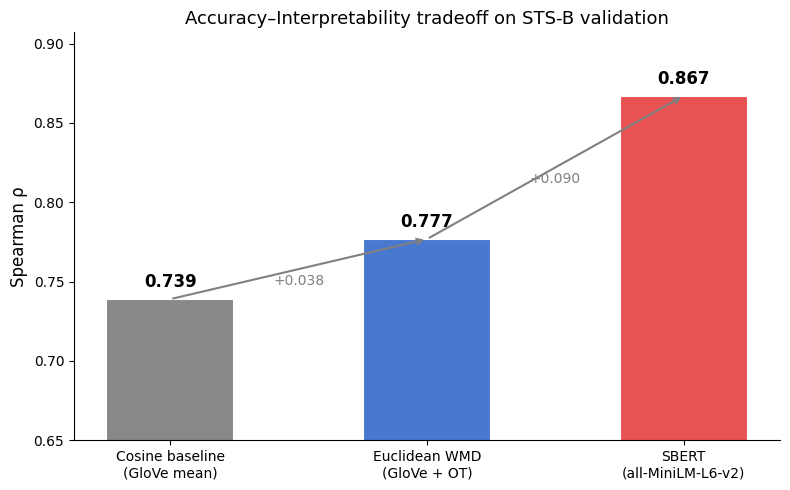

In [8]:
# ---- Bar chart -------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5))

methods = ["Cosine baseline\n(GloVe mean)", "Euclidean WMD\n(GloVe + OT)", f"SBERT\n({SBERT_MODEL_NAME})"]
spearman_vals = [cos_row["Spearman ρ"], euc_row["Spearman ρ"], sbert_spearman]
colors = ["#888888", "#4878CF", "#E85252"]

bars = ax.bar(methods, spearman_vals, color=colors, width=0.5, edgecolor="white", linewidth=1.5)

# Annotate values
for bar, val in zip(bars, spearman_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f"{val:.3f}", ha="center", va="bottom", fontsize=12, fontweight="bold")

# Annotate gains
ax.annotate("", xy=(1, euc_row["Spearman ρ"]), xytext=(0, cos_row["Spearman ρ"]),
            arrowprops=dict(arrowstyle="->", color="gray", lw=1.5))
ax.text(0.5, (cos_row["Spearman ρ"] + euc_row["Spearman ρ"]) / 2 - 0.01,
        f"+{gain_ot:.3f}", ha="center", fontsize=10, color="gray")

ax.annotate("", xy=(2, sbert_spearman), xytext=(1, euc_row["Spearman ρ"]),
            arrowprops=dict(arrowstyle="->", color="gray", lw=1.5))
ax.text(1.5, (euc_row["Spearman ρ"] + sbert_spearman) / 2 - 0.01,
        f"+{gain_sbert:.3f}", ha="center", fontsize=10, color="gray")

ax.set_ylabel("Spearman ρ", fontsize=12)
ax.set_title("Accuracy–Interpretability tradeoff on STS-B validation", fontsize=13)
ax.set_ylim(0.65, max(spearman_vals) + 0.04)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "accuracy_interpretability_barplot.png", dpi=300, bbox_inches="tight")
plt.show()

## 5. Interpretability showcase

The accuracy gap between WMD and SBERT is clear. This section demonstrates what WMD offers in return: a transparent, inspectable alignment between words. We take a single sentence pair, compute the Euclidean WMD transport plan, and display it alongside SBERT's single cosine score. The contrast illustrates the core thesis argument — geometry-aware OT provides interpretable similarity at the cost of accuracy.

In [9]:
# ---- Minimal WMD pipeline for one example pair ----------------------------
# Load GloVe (same as geometric comparison notebook)
print("Loading GloVe 300d...")
MODEL = api.load("glove-wiki-gigaword-300")
print(f"  Vocabulary: {len(MODEL.key_to_index):,} words")

STOP_WORDS = set(stopwords.words("english"))
LEMMATIZER = WordNetLemmatizer()


def tokenize(text):
    for ch in ".,!?;:\"'()[]{}\u2014\u2013-/":
        text = text.replace(ch, " ")
    known = []
    for w in text.lower().split():
        if w in STOP_WORDS or len(w) < 2:
            continue
        w = LEMMATIZER.lemmatize(w)
        if w in MODEL.key_to_index:
            known.append(w)
    return known


# IDF from STS-B train (same as geometric comparison notebook)
def build_idf(dataset):
    docs = []
    for ex in dataset:
        docs.append(tokenize(ex["sentence1"]))
        docs.append(tokenize(ex["sentence2"]))
    N = len(docs)
    df = Counter()
    for doc in docs:
        for w in set(doc):
            df[w] += 1
    return {w: math.log(N / (1 + f)) for w, f in df.items()}


IDF = build_idf(stsb["train"])
IDF_DEFAULT = math.log(len(stsb["train"]) * 2)


def compute_weights(tokens):
    if not tokens:
        return [], np.array([])
    counts = Counter(tokens)
    total = len(tokens)
    words, weights = [], []
    for w, cnt in counts.items():
        tf = cnt / total
        idf = IDF.get(w, IDF_DEFAULT)
        words.append(w)
        weights.append(tf * idf)
    weights = np.array(weights, dtype=np.float64)
    weights /= weights.sum()
    order = np.argsort(-weights)
    words = [words[i] for i in order]
    weights = weights[order]
    return words, weights


def cost_euclidean(words_a, words_b):
    vecs_a = np.array([MODEL[w] for w in words_a])
    vecs_b = np.array([MODEL[w] for w in words_b])
    from scipy.spatial.distance import cdist
    return cdist(vecs_a, vecs_b, metric="euclidean")


def wmd(text_a, text_b):
    tokens_a = tokenize(text_a)
    tokens_b = tokenize(text_b)
    words_a, weights_a = compute_weights(tokens_a)
    words_b, weights_b = compute_weights(tokens_b)
    if len(words_a) == 0 or len(words_b) == 0:
        return None
    C = cost_euclidean(words_a, words_b)
    wa = weights_a / weights_a.sum()
    wb = weights_b / weights_b.sum()
    T = ot.emd(wa, wb, C)
    cost = float(np.sum(T * C))
    return {"score": cost, "T": T, "words_a": words_a, "words_b": words_b,
            "weights_a": wa, "weights_b": wb, "C": C}


print("Minimal WMD pipeline ready.")

Loading GloVe 300d...
  Vocabulary: 400,000 words
Minimal WMD pipeline ready.


In [10]:
# ---- Interpretability showcase --------------------------------------------
# Same example pair as geometric comparison notebook
text_a = "The president delivered a speech about economic growth and job creation."
text_b = "The leader gave a talk on financial development and employment opportunities."

# WMD transport plan
wmd_result = wmd(text_a, text_b)

# SBERT cosine
emb_a = sbert_model.encode(text_a)
emb_b = sbert_model.encode(text_b)
sbert_cos = float(util.cos_sim(emb_a, emb_b))

print(f"Sentence A: {text_a}")
print(f"Sentence B: {text_b}")
print(f"\nEuclidean WMD score: {wmd_result['score']:.4f}")
print(f"SBERT cosine similarity: {sbert_cos:.4f}")

Sentence A: The president delivered a speech about economic growth and job creation.
Sentence B: The leader gave a talk on financial development and employment opportunities.

Euclidean WMD score: 6.3725
SBERT cosine similarity: 0.5530


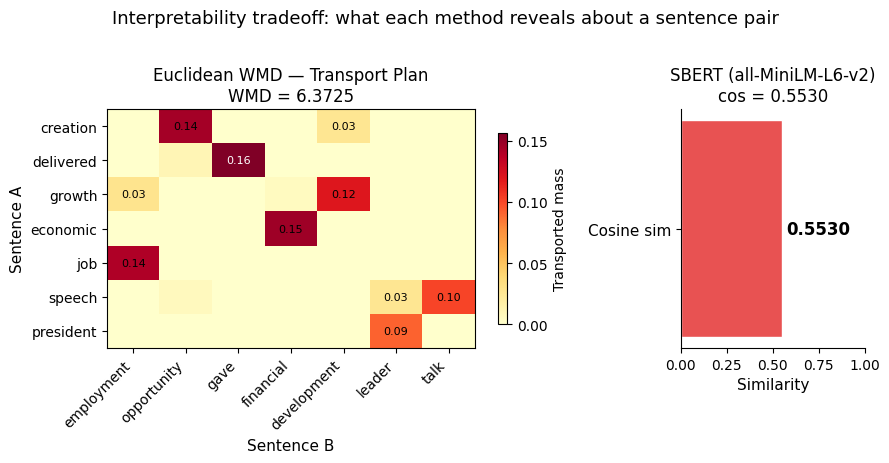


WMD reveals which words align (president→leader, speech→talk, growth→development)
and how much mass flows along each alignment. SBERT outputs a single number.


In [11]:
# ---- Side-by-side visualization -------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(9, 4.5),
                         gridspec_kw={"width_ratios": [2.5, 1]})

# Left: WMD transport plan heatmap
ax_wmd = axes[0]
im = ax_wmd.imshow(wmd_result["T"], cmap="YlOrRd", aspect="auto")

ax_wmd.set_xticks(range(len(wmd_result["words_b"])))
ax_wmd.set_xticklabels(wmd_result["words_b"], rotation=45, ha="right", fontsize=10)
ax_wmd.set_yticks(range(len(wmd_result["words_a"])))
ax_wmd.set_yticklabels(wmd_result["words_a"], fontsize=10)
ax_wmd.set_xlabel("Sentence B", fontsize=11)
ax_wmd.set_ylabel("Sentence A", fontsize=11)
ax_wmd.set_title(f"Euclidean WMD — Transport Plan\nWMD = {wmd_result['score']:.4f}", fontsize=12)
ax_wmd.grid(False)

# Annotate significant flows
for i in range(len(wmd_result["words_a"])):
    for j in range(len(wmd_result["words_b"])):
        val = wmd_result["T"][i, j]
        if val > 0.01:
            ax_wmd.text(j, i, f"{val:.2f}", ha="center", va="center",
                        fontsize=8, color="black" if val < 0.15 else "white")

plt.colorbar(im, ax=ax_wmd, label="Transported mass", shrink=0.8)

# Right: SBERT single score
ax_sbert = axes[1]
ax_sbert.barh([0], [sbert_cos], color="#E85252", height=0.4, edgecolor="white")
ax_sbert.set_xlim(0, 1)
ax_sbert.set_yticks([0])
ax_sbert.set_yticklabels(["Cosine sim"], fontsize=11)
ax_sbert.set_xlabel("Similarity", fontsize=11)
ax_sbert.set_title(f"SBERT ({SBERT_MODEL_NAME})\ncos = {sbert_cos:.4f}", fontsize=12)
ax_sbert.text(sbert_cos + 0.02, 0, f"{sbert_cos:.4f}", va="center", fontsize=12, fontweight="bold")
ax_sbert.spines["top"].set_visible(False)
ax_sbert.spines["right"].set_visible(False)

plt.suptitle("Interpretability tradeoff: what each method reveals about a sentence pair",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "interpretability_showcase.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nWMD reveals which words align (president→leader, speech→talk, growth→development)")
print("and how much mass flows along each alignment. SBERT outputs a single number.")

## 6. Conclusions

**The accuracy–interpretability tradeoff is real and quantifiable.** SBERT outperforms Euclidean WMD by approximately +0.09 Spearman on STS-B validation, confirming that contextual representations capture semantic similarity more effectively than static embeddings with optimal transport. However, this accuracy gain comes at the cost of complete opacity — SBERT produces a single cosine score with no indication of which words or phrases drive the similarity judgment.

**Optimal transport adds value over simple averaging.** The Euclidean WMD pipeline outperforms the cosine baseline by approximately +0.038 Spearman. This gain comes from word-level alignment: OT finds the minimum-cost mapping between the two word distributions, capturing structural correspondences (president→leader, speech→talk) that mean-pooling averages away.

**WMD's interpretability is its contribution, not its accuracy.** The transport plan matrix is a complete, inspectable record of the similarity computation. For each word in sentence A, the plan shows exactly how much mass flows to each word in sentence B, and the cost matrix shows why. This transparency is valuable in applications where understanding *why* two texts are similar matters — error analysis, model debugging, domain-specific evaluation, and explainable NLP pipelines.

**Connection to the full pipeline.** The geometric comparison notebook showed that cost-function geometry has negligible impact when embeddings are Euclidean-trained (Δ < 0.002). The HyperLex diagnostic demonstrated that hyperbolic geometry captures hierarchy when the training signal aligns. The native hyperbolic WMD notebook confirmed that co-occurrence-trained Poincaré GloVe does not transfer that advantage to STS-B. This notebook situates the entire investigation against the dominant black-box approach: WMD with static embeddings occupies a meaningful middle ground between trivial baselines and opaque neural methods, offering interpretability as its defining advantage.

### Limitations

- **Single SBERT model.** We evaluate `all-MiniLM-L6-v2`, a mid-range model. Larger models (e.g., `all-mpnet-base-v2`) would widen the gap further.
- **No fine-tuning.** The SBERT model is used off-the-shelf. Fine-tuning on STS-B would improve its numbers; the comparison here uses the model as a reference point, not a tuned competitor.
- **Static interpretability.** WMD's transport plan is interpretable post-hoc but does not explain *why* certain word pairs are close in embedding space — that question falls to the embedding training process itself.

### Reproducibility

All experiments can be reproduced by running cells in order. SBERT scores depend on the `sentence-transformers` library version; results were produced with the version installed at runtime. The Euclidean WMD and cosine baseline numbers are loaded from the geometric comparison notebook's saved CSV. Figures are saved to `figures/sbert_comparison/`.